# Implementing Discrete Namouni Mapping Using Individual Orbital Elements

S. Trongdee
05/26/2026

We already have the code for the first-order Namouni mapping (equations C.1.34-41 in Lizzy's thesis) in both original and ODE versions. However, to keep track of changes in the three-planet system, it would be more convenient if the mapping could just take the elements from each planet and output them at the next conjunction right away without finding relative values.

Because the three-body resonances can come from the overlapping of two two-body resonances, one from the inner pair (inner massive planet and middle massless test particle) and another from the outer pair (middle massless test particle and outer massive planet), we should be able to simulate both pairs and see if the Namouni mapping works for the outer pair! (Lizzy's thesis only considered the inner pair.)

In this notebook, we have the Namouni mapping equations implemented in three versions: original discrete mapping that takes in the relative eccentricity and semimajor axis, the smoothed-out version that is written as a system of coupled differential equations, and the new version where we can input the individual orbital elements involved in the evolution during the conjunction and output the individual orbital elements.

(Update: 06/11/2026) We are also trying to implement the second-order Namouni mapping in the same manners as well to tackle the lower eccentricity limit. This notebook will include the interface where you can select the mapping order.

In [1]:
# First, import some vital stuff

import matplotlib.pyplot as plt
import rebound
import numpy as np
import pandas as pd
import scipy
import math
import random
from scipy.optimize import minimize
from scipy.signal import find_peaks

The setup code below also take the index of the massive planet to indicate whether it is an inner or outer pair. It is written so that it can line up the first conjunction at t=0 at our desired angle and take some steps back so that this first conjunction is detectable. Note that the orbital shape might have changed as the planets move and interact, and the position of the conjunction might have been deviated. We need to take that change into account.

The code guesses the value of $\lambda$, the mean longitude, at conjunction, and uses variational equations (derivatives in REBOUND) to find the correction according to the first-order expansion:
$$
\begin{align*}
\lambda_{\text{target}} &= \lambda_0 + \frac{d \lambda_{\text{target}}}{d\lambda}(\lambda-\lambda_0)
\end{align*}
$$
The code iterates to some number of times until we get the value close to our desired value.

In [2]:
def setup_tri(j, k, mutot, etilde, pomega2, lambda_target, ind, iterations = 11):
    '''
    Set up the two-planet system where one planet is massive with circular orbit 
    and the other is massless with eccentric orbit. The period ratio of the outer to the inner is j:j-k.
    The order where these planets appear can be specified.
    '''
    ecross = 2*k/(3*j)
    n1 = 2*np.pi
    n2 = n1*(j-k)/j
    tconj = 2*np.pi/(n1-n2) # estimate for time between conjunctions
    t0 = -0.7*tconj

    lambda10 = lambda_target+n1*t0 # this should be exact since 
    lambda20 = lambda_target + n2*t0 + 1e-4

    if ind == 1: #inner pair
        lambda_20_prev = lambda20 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_20 = lambda_20_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
            sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
            var_l = sim.add_variation()
            var_l.vary(2, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
        
            sim.integrate(0)
            correction = (lambda_target - ps[2].l)/var_l.particles[2].l
            lambda_20_prev = lambda_20
            #print('***',i,'***')
            print(lambda_target-ps[2].l, var_l.particles[2].l)
        
       
        lambda_20 = lambda_20_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], m=mutot, P=1, l=lambda10)
        sim.add(primary=sim.particles[0], P=j/(j-k), e=etilde*ecross, pomega=pomega2, l=lambda_20)
    else: #outer pair
        lambda_10_prev = lambda10 # initial guess
        correction = 0
        for i in range(iterations):
            lambda_10 = lambda_10_prev + correction
            sim = rebound.Simulation()
            sim.add(m=1)
            sim.add(primary=sim.particles[0],P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
            sim.add(primary=sim.particles[0],m=mutot, P=j/(j-k), l=lambda20)
            var_l = sim.add_variation()
            var_l.vary(1, 'l') # how does everything depend on the initial l of particles[2]
            sim.t = t0
            ps = sim.particles
        
            sim.integrate(0)
            correction = (lambda_target - ps[1].l)/var_l.particles[1].l
            lambda_10_prev = lambda_10
            #print('***',i,'***')
            print(lambda_target-ps[2].l, var_l.particles[1].l)
        
       
        lambda_10 = lambda_10_prev + correction
        sim = rebound.Simulation()
        sim.add(m=1)
        sim.add(primary=sim.particles[0], P=1,e=etilde*ecross, pomega=pomega2, l=lambda_10)
        sim.add(primary=sim.particles[0], m=mutot, P=j/(j-k), l=lambda20)
    sim.t = t0
    return sim

In [3]:
def unwrap_l(ps):
    ''' given a sim.particles object ps, returns relative lambda (l) value of the planets
        removing the 2*pi discontinuities that result when one planet has crossed l=0 but
        the other has not
    '''
    if ps[2].l - ps[1].l > np.pi:
        return ps[2].l - ps[1].l - 2*np.pi
    elif ps[2].l - ps[1].l < -np.pi:
        return ps[2].l - ps[1].l + 2*np.pi
    else:
        return ps[2].l - ps[1].l

In [4]:
def new_run(sim, Nconj, Nout):
    '''
    This function runs the Nbody simulation until we get Nconj conjunctions 
    and save the orbital parameters and conjunction times.
    '''
    # this function now saves individual semimajor axis length and other individual variables (will keep adding)
    ps = sim.particles
    n1 = ps[1].n
    n2 = ps[2].n
    tmin = sim.t
    #print(tmin)
    tconj = 2*np.pi/(n1-n2)
    tmax = Nconj*tconj + 0.5*tmin

    a12_arr, l12_arr, l2, theta_arr, pomega_arr, e12_arr, diffn_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    e1, e2, pomega1, pomega2, a1_arr, a2_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    times = np.linspace(tmin, tmax, Nout)
    #print(times)
    for i, time in enumerate(times):
        a12_arr[i] = (ps[2].a - ps[1].a)/ps[1].a # relative semimajor axis
        a1_arr[i] = ps[1].a
        a2_arr[i] = ps[2].a
        l12_arr[i] = unwrap_l(ps) 
        e1_vec_temp= ps[1].e * np.exp(1j * ps[1].pomega)
        e2_vec_temp= ps[2].e * np.exp(1j * ps[2].pomega)
        pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
        e12_temp = np.abs(e2_vec_temp-e1_vec_temp)
        theta_arr[i] = ps[2].l - pomega12_temp

        l2[i] = ps[2].l
        pomega_arr[i] = pomega12_temp
        e12_arr[i] = e12_temp

        e1[i] = ps[1].e
        e2[i] = ps[2].e
        pomega1[i] = ps[1].pomega
        pomega2[i] = ps[2].pomega
        diffn_arr[i] = ps[1].n - ps[2].n
        sim.integrate(time)
        
    l2 = np.unwrap(l2)
    
    # conjunctions occur at minima pf dl = maxima of -dl
    conj_idx, _ = find_peaks(-np.abs(l12_arr))
    if len(conj_idx) != Nconj:
        print("WARNING: wrong number of conjunction events found \n {} conjunctions found, {} conjunctions input".format(len(conj_idx), Nconj))
        #raise Exception('''wrong number of conjunction events found \n {} conjunctions found, 
        #                {} conjunctions input'''.format(len(conj_idx), Nconj))
    #pts_btwn_conj = (.5*np.diff(conj_idx)).astype(np.int64)

    btwn_conj_idx, properties = find_peaks(np.abs(l12_arr))
    #btwn_conj_idx[1:] = conj_idx[:-1] + pts_btwn_conj

    return [times, a12_arr, l12_arr, theta_arr, l2, pomega_arr, e12_arr, e1, e2, pomega1, pomega2, diffn_arr, conj_idx, btwn_conj_idx, a1_arr, a2_arr]


In [5]:
def wrap_angles(angles):
    return (angles + np.pi) % (2 * np.pi) - np.pi

Here we have the homemade integrator that solves the differential equations from the Namouni mapping.

In [6]:
#Integrator for our setup
def integrate_3br_2(func, y0, t, dt, args=()):
    """
    General symplectic integrator (odeint-compatible API).

    Parameters
    ----------
    func : callable
        Function f(y, t, *args) returning dy/dt as 1D array of len(y0).
        First half of y are "positions" q, second half "momenta" p.
    y0 : array_like
        Initial state vector [q1, ..., qN, p1, ..., pN].
        Must have even length.
    t : array_like
        Times at which to output the solution.
    args : tuple, optional
        Additional parameters for func.
    dt : float, optional
        Internal integration timestep. Defaults to min(diff(t)) / 10.

    Returns
    -------
    y_out : ndarray
        Array of shape (len(t), len(y0)) containing y(t) at each output time.
    """
    t = np.asarray(t, dtype=float)
    t_max = t[-1]
    numout = len(t)
    numpara = len(y0)
    y_out = np.zeros((numout, numpara)) #array to store the solution
    next_index = 0
    t_curr = 0
    for step in range(int(t_max/dt)+2):
        #update at conjunction only - same logic as update at any desired time!
        #the >= sign in the second condition ensures that if the time after increment is slightly off we still have something
        #otherwise we won't get the solution at that point
        while next_index < numout and t_curr >= t[next_index]:
            y_out[next_index] = y0
            next_index += 1
            
        #step update using the derivative calculated at the latest conjunction
        dydt = np.asarray(func(y_out[next_index-1], t_curr, *args), dtype = float)
        y0 += dydt*dt
        t_curr += dt

    return y_out

Now we define a function that evaluates the derivative. The parameters we can change into continuous functions are $h$, $k$, $K$, and $\lambda$. See that the derivatives can be approximated by the (small) differences between two neighboring values of indices $n+1$ and $n$ over the time interval between two closest conjunctions. That is,
$$
\begin{align}
\dot{h}\approx \frac{\delta h}{\Delta t_{\text{conj}}} &= \frac{2W_{1}^{1,0}}{a_r^2\Delta t_{\text{conj}}}\sin\lambda \\
\dot{k}\approx \frac{\delta k}{\Delta t_{\text{conj}}} &= -\frac{2W_{1}^{1,0}}{a_r^2\Delta t_{\text{conj}}}\cos\lambda \\
\dot{K}\approx \frac{\delta K}{\Delta t_{\text{conj}}} &= \frac{\delta I}{\Delta t_{\text{conj}}} \\
&=\frac{h\delta h}{\Delta t_{\text{conj}}}+\frac{k\delta k}{\Delta t_{\text{conj}}} \\
&=\frac{2W_{1}^{1,0}}{a_r^2\Delta t_{\text{conj}}}(h\sin\lambda-k\cos\lambda) \\
\dot{\lambda}\approx \frac{\delta \lambda}{\Delta t_{\text{conj}}} &= \frac{4\pi}{\Delta t_{\text{conj}}\epsilon\sqrt{24 K}}
\end{align}
$$
These equations resemble those in Namouni mapping, but we have thrown the discrete indices away, and they are divided by $\Delta t_{\text{conj}}$! Here, we treat $\Delta t_{\text{conj}}$ as a constant, as it changes slightly in the simulation, and use its average value.

In [7]:
#Change Namouni mapping into coupled differential equations
def derivatives(z, t, W1, ar0, epsilon, dtconj):
    #print(z)
    #z is the current state where we want to know the derivative
    h, k, K, lamb = z
    c1 = 2*W1/ar0**2/dtconj
    c2 = 4*np.pi/(np.sqrt(24)*epsilon)/dtconj
    return [c1*np.sin(lamb), -c1*np.cos(lamb), h*c1*np.sin(lamb)-k*c1*np.cos(lamb), c2/np.sqrt(K)]

We can also write the system of differential equations that represent the second-order mapping in a similar manner. (This is still work in progress)

In [8]:
def derivatives_so(z, t, W1, W2, W200, ar0, epsilon, dtconj):
    #print(z)
    #z is the current state where we want to know the derivative
    h, k, K, phi, lamb = z
    phi_prime = np.arctan2(k,h)
    c1 = 2*W1/ar0**2/dtconj
    c2 = 4*np.pi/(np.sqrt(24)*epsilon)/dtconj
    c3 = (1 + 8*W2*np.sin(2*(phi_prime-lamb))/ar0**3)
    c4 = 2*W200/dtconj/ar0**3
    c5 = 4*W2/dtconj/ar0**3
    return [c1*np.sin(lamb), -c1*np.cos(lamb), (h*c1*np.sin(lamb)-k*c1*np.cos(lamb))/(1 + 8*W2*np.sin(2*(phi_prime-lamb))/ar0**3), -(c4+c5*np.cos(2*(phi_prime-lamb))), c2/np.sqrt(K)]

Now we're ready to create a setup. First, we specify the parameters we want for our system and how we want it to look like. We can also choose the order of the mapping and the pair of planets we want to simulate.

In [9]:
#Parameters and initial conditions
#mean motion resonance ratio
j = 11
k = 1
mutot = 3e-8 #mass of the planet
etilde=0.001 #eccentricity
pomega2=0
lambda_target=np.pi/6 # where we want conjunction to happen/ analogous to lambda0 in lizzy's
Nconj = 1000 #number of conjunctions
Nout = Nconj*100
ind = 3 # 1 for inner pair, 3 for outer pair
order = 1 # mapping order: 1 for first, 2 for second

-9.999999997878373e-05 2.094722045543814
-9.999999999477094e-05 2.0947385391568263
-9.999999999388276e-05 2.0947471609257216
-0.00010000000000542908 2.0947516678680884
-9.999999998588915e-05 2.094754023841542
-9.999999999033005e-05 2.094755255411166
-9.999999997700737e-05 2.094755899212111
-0.0001000000000169754 2.094756235754134
-0.0001000000000045409 2.094756411680356
-9.999999994503295e-05 2.094756503643504
-0.00010000000000010001 2.094756551717748


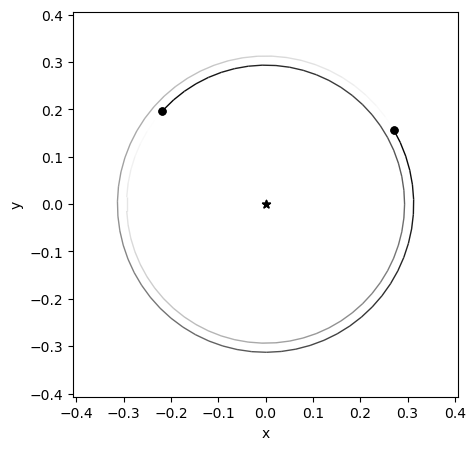

In [10]:
#Setup the nbody simulation to extract initial parameters and save others to compare
#sim = setup_dup(j,k,mutot,etilde,pomega2,lambda_target)
sim = setup_tri(j,k,mutot,etilde,pomega2,lambda_target,ind)
ps = sim.particles
#print(ps[2].e)
rebound.OrbitPlot(sim)

Now, we are ready to integrate using REBOUND for some amount of conjunctions! Here, we also save the parameters between the conjunctions to use in and compare with the Namouni mapping. We are not using some parameters during exactly the conjunction because the conjunction can cause a spike in the value before it returns to the new one after the interaction ends, which is why we find the values between conjunctions more representative. The smooth model also removes those spikes at conjunctions.

In [11]:
#parameters from simulation
times, a12, l12, theta2, l2, pomega12, e12, e1, e2, pomega1, pomega2, diffn_arr, conj_idx, btwn_conj_idx, a1_arr, a2_arr = new_run(sim, Nconj, Nout)
tconjs = times[conj_idx]  
tbetweens = times[btwn_conj_idx]  
an = a12[btwn_conj_idx]              # Relative semimajor axis
e12n = e12[btwn_conj_idx]            # Relative eccentricity
#individual values
a1_conj = a1_arr[btwn_conj_idx] 
a2_conj = a2_arr[btwn_conj_idx]
e1_conj = e1[btwn_conj_idx]
e2_conj = e2[btwn_conj_idx]
pomega1_conj = pomega1[btwn_conj_idx]
pomega2_conj = pomega2[btwn_conj_idx]
pomegan = pomega12[btwn_conj_idx]    # Relative periapse
lambdan = l2[conj_idx]               # Lambda at conjunctions
diffnconj = diffn_arr[conj_idx]

The mapping only cares about the values at conjunction, so we need to take the parameters from the first conjunction in Nbody and set them as the initial values in the mapping. This is why we want the first conjunction to happen at t=0!

In [12]:
#extract values for Namouni mapping and use in the equations
epsilon = (mutot/3)**(1/3)                      # Small mass parameter
print(epsilon)
ar0 = an[0] / epsilon                           # Initial scaled semimajor axis
K0 = 3/8*ar0**2
I0 = (e12n[0]/epsilon)**2 / 2                   # Initial action
phi0 = pomega12[0]                              # Initial pericenter
lambda0 = lambdan[0]                            # Initial conj angle

#eccentricity vector components
h0 = np.sqrt(2*I0)*np.cos(phi0)
k0 = np.sqrt(2*I0)*np.sin(phi0)

print(lambda_target, np.mod(lambda0, 2*np.pi), h0, k0, I0,K0)

0.0021544346900318843
0.5235987755982988 0.5395325609103381 -0.028127980046334457 -1.231989846345965e-14 0.0003955916307434947 347.6941891788809


We should also be able to calculate the actual times between two consecutive conjunctions from the simulation. Their average gives the $\Delta t_{\text{conj}}$ we need for the smooth model.

In [13]:
#average delta tconj for the smooth function approximation
deltatconj = np.diff(tconjs) # find all possible time intervals between two adjacent conjunctions
deltatconj_fixed = []
for deltat in deltatconj:
    # There are some outliers that are less than 11, so we have to filter out. This number is from inspection, no science involved.
    if(deltat > 11):
        deltatconj_fixed.append(deltat)
dtconj = np.mean(deltatconj_fixed) 
print(dtconj)

11.003960039600418


This is the first- and second-order Namouni mappings for one step. The second-order mapping can be useful when the eccentricity is very small because it contains the second order corrections in the eccentricity vector. 

In [14]:
#Namouni mapping setup
W1, W2, W3, W4, W200 = 3.359, -2.678665722, 2.639498803, 2.8559, -1 #constants from the expansion

#%% Namouni Mapping Functions
def calc_coeff(q, Wq, ar, theta):
    """Coefficient for power series in Namouni for the q'th order (derivatives of W wrt phi)."""
    return 2*q*2**(q/2)*Wq*np.sin(2*theta)/ar**(q+1)

def namouni_fo_step(In, Kn, phin, lambdan, arn):
    """First-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    hprime = hn + 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
    kprime = kn - 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    #print(hn, kn)
    # both options should give the same result:
    Inprime = 1/2*(hprime**2 + kprime**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4

    Inp1 = Inprime
    phinp1 = phiprime
    Knp1 = Kn + Inp1 - In
    hnp1 = hprime
    knp1 = kprime
    lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

def namouni_so_step(In, Kn, phin, lambdan, arn):
    """Second-order Namouni mapping step."""
    hn = np.sqrt(2*In)*np.cos(phin)
    kn = np.sqrt(2*In)*np.sin(phin)
    hprime = hn - 2*W1*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
    kprime = kn + 2*W1*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = phiprime - lambdan

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    hnp1 = hprime
    knp1 = kprime
    Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
    return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

Here is our new version of Namouni mapping that takes in the individual orbital parameters for both first and second orders.

In [15]:
def namouni_fo_step_abs(e1_vecarr_n, e2_vecarr_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
    Kn = 3*ar_n**2/8
    e12_arr = [e2_vecarr_n[0]-e1_vecarr_n[0], e2_vecarr_n[1]-e1_vecarr_n[1]]
    
    pomega12_temp = np.arctan2(e12_arr[1],e12_arr[0])
    e12_temp = np.sqrt((e12_arr[0])**2+(e12_arr[1])**2)
    In = (e12_temp/epsilon)**2 / 2  
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp

    #mapping calculation
    hnp1 = hn + 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
    knp1 = kn - 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    #phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    
    # both options should give the same result:
    Inp1 = 1/2*(hnp1**2 + knp1**2)
    #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
    
    #phinp1 = phiprime
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = [hnp1*epsilon, knp1*epsilon]
    arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
    if ind==1: #inner pair
        e1np1 = e1_vecarr_n
        a1np1 = a1_conj_n
        e2np1 = [e1_vecarr_n[0]+e12vec[0], e1_vecarr_n[1]+e12vec[1]]
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        e1np1 = [e2_vecarr_n[0]-e12vec[0], e2_vecarr_n[1]-e12vec[1]]
        a1np1 = a2_conj_n - arnp1
        e2np1 = e2_vecarr_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

In [16]:
def namouni_so_step_abs(e1_vecarr_n, e2_vecarr_n, a1_conj_n, a2_conj_n, lambdan_n, ind):
    #second order Namouni mapping that inputs and outputs individual values instead of the relative ones
    #hard calculate the relative values
    #print(e1_0, e2_0, pomega1_0, pomega2_0, a1_conj_0, a2_conj_0, lambdan_0)
    ar_n = (a2_conj_n-a1_conj_n)/a1_conj_n/epsilon
    Kn = 3*ar_n**2/8
    e12_arr = [e2_vecarr_n[0]-e1_vecarr_n[0], e2_vecarr_n[1]-e1_vecarr_n[1]]
    
    pomega12_temp = np.arctan2(e12_arr[1],e12_arr[0])
    e12_temp = np.sqrt((e12_arr[0])**2+(e12_arr[1])**2)
    In = (e12_temp/epsilon)**2 / 2  
    hn = np.sqrt(2*In)*np.cos(pomega12_temp)
    kn = np.sqrt(2*In)*np.sin(pomega12_temp)  
    #phi0 = pomega12_temp
    
    hprime = hn - 2*W1*np.sin(lambdan_n)/ar_n**2 # + for Namouni, - for pomega
    kprime = kn + 2*W1*np.cos(lambdan_n)/ar_n**2 # - for Namouni, + for pomega
    phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
    thetaprime = phiprime - lambdan_n

    # A = calc_coeff(2, W2, arn, thetaprime)
    # E1 = 1/(1+A)
    # Inp1 = E1*Inprime
    hnp1 = hprime
    knp1 = kprime
    Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/ar_n**3)
    phinp1 = phiprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/ar_n**3
    Knp1 = Kn + Inp1 - In
    lambdanp1 = lambdan_n + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))

    
    #e12np1_mag = np.sqrt(2*Inp1)*epsilon
    e12vec = [hnp1*epsilon, knp1*epsilon]
    arnp1 = np.sqrt(8*Knp1/3)*epsilon*a1_conj_n
    if ind==1: #inner pair
        e1np1 = e1_vecarr_n
        a1np1 = a1_conj_n
        e2np1 = [e1_vecarr_n[0]+e12vec[0], e1_vecarr_n[1]+e12vec[1]]
        a2np1 = a1_conj_n+arnp1
    else: #outer pair
        e1np1 = [e2_vecarr_n[0]-e12vec[0], e2_vecarr_n[1]-e12vec[1]]
        a1np1 = a2_conj_n - arnp1
        e2np1 = e2_vecarr_n
        a2np1 = a2_conj_n
    return e1np1, e2np1, a1np1, a2np1, lambdanp1
# optimize K and get the optimized a2 initial condition

In [17]:
#extract eccentricity vector components
e1_vec = e1_conj[0] * np.exp(1j * pomega1_conj[0])
e1_vecarr = [np.real(e1_vec), np.imag(e1_vec)]
e2_vec = e2_conj[0] * np.exp(1j * pomega2_conj[0])
e2_vecarr = [np.real(e2_vec), np.imag(e2_vec)]
print(e1_vecarr, e2_vecarr)

[6.059989320037009e-05, -1.8329279144230244e-08] [-4.993762071266511e-18, 2.8430791543618423e-16]


Now we implement the function to run the mapping for multiple steps. We can select order of the mapping we want to use. For the version that takes in the individual values, we have to specify which pair (inner or outer).

In [18]:
#This function runs Namouni mapping for multiple conjunctions
def runmap(I0, K0, phi0, lambda0, Nconj, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        K0 = K0[0]
    except:
        pass
    Is, Ks, phis, lambdas, hs, ks = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    Is[0] = I0
    Ks[0] = K0
    phis[0] = phi0
    lambdas[0] = lambda0
    ar0 = np.sqrt(8*K0/3)

    for i in range(Nconj):
        if order==1:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_fo_step(Is[i], Ks[i], phis[i], lambdas[i], ar0)
        else:
            Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = namouni_so_step(Is[i], Ks[i], phis[i], lambdas[i], ar0)

    return Is, Ks, phis, lambdas, hs, ks

In [19]:
#This function runs Namouni mapping for multiple conjunctions
#But for individual parameters
def runmap_abs(e1_vecarr, e2_vecarr, a1_conj_0, a2_conj_0, lambdan_0, Nconj, ind, order):
    try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
        a1_conj_0 = a1_conj_0[0]
    except:
        pass
    e1_s, e2_s, a1_s, a2_s, lambda_s = np.zeros((Nconj+1,2)), np.zeros((Nconj+1,2)), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
    #print(e1_vecarr, e2_vecarr)
    e1_s[0,0] = e1_vecarr[0]
    e1_s[0,1] = e1_vecarr[1]
    e2_s[0,0] = e2_vecarr[0]
    e2_s[0,1] = e2_vecarr[1]
    #print(e1_s[0], e2_s[0])
    #print(a1_conj_0, a2_conj_0)
    a1_s[0] = a1_conj_0
    a2_s[0] = a2_conj_0
    lambda_s[0] = lambdan_0
    #ar0 = np.sqrt(8*K0/3)
    for i in range(Nconj):
        if order==1:
            e1_np1, e2_np1, a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_fo_step_abs([e1_s[i,0],e1_s[i,1]], [e2_s[i,0],e2_s[i,1]], a1_s[i], a2_s[i], lambdas[i],ind)
        else:
            e1_np1, e2_np1, a1_s[i+1], a2_s[i+1], lambda_s[i+1] = namouni_so_step_abs([e1_s[i,0],e1_s[i,1]], [e2_s[i,0],e2_s[i,1]], a1_s[i], a2_s[i], lambdas[i],ind)            
        e1_s[i+1,0] = e1_np1[0]
        e1_s[i+1,1] = e1_np1[1]
        e2_s[i+1,0] = e2_np1[0]
        e2_s[i+1,1] = e2_np1[1]

    return e1_s, e2_s, a1_s, a2_s, lambda_s

In [20]:
#Then save into arrays to compare with the simulation and the equation
Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0, phi0, lambda0, Nconj, order)
print(lambdas)

[4.45218297e+01 1.08373497e+02 1.72225178e+02 ... 6.37684927e+04
 6.38323444e+04 6.38961961e+04]


In [21]:
e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vecarr, e2_vecarr, a1_conj[0], a2_conj[0], lambda0, Nconj, ind, order)
print(lambda_s)

[4.45218297e+01 1.08373497e+02 1.72225179e+02 ... 6.37684927e+04
 6.38323444e+04 6.38961961e+04]


At the beginning, we matched $\lambda$ at the first conjunction with the target value we want. However, as we keep running for multiple conjunctions, the deviation of the mapping values from the simulation starts to grow, so we need to find the value of the semimajor axis of the test particle (which in turn is related to $K$ in the mapping) that minimizes this deviation.

In [22]:
def prnt(intermediate_result):
    print(intermediate_result)
    #print(intermediate_result.x, intermediate_result.fun)

In [23]:
#This optimizes the initial conditions so that nbody and Namouni mapping (and hopefully the differential equations) match
def lambda_RMS(K0, I0, phi0, lambda0, Nconj, lambdan):
    K0 = [K0]
    Is, Ks, phis, lambdas, hs, ks = runmap(I0, K0[0], phi0, lambda0, Nconj, order)
    return np.mean((lambdas[:-1] - lambdan)**2) # RMS remove last lambda which corresponds to N+1th conj

result = minimize(lambda_RMS, K0, args=(I0, phi0, lambda0, Nconj, lambdan), callback=prnt)
Kopt = result.x[0]

print(f"Optimal x: {Kopt}")
print(f"Minimum function value: {result.fun}")
print(f"Success: {result.success}")
print(f"Message: {result.message}")

 fun: 110386.8414910373
   x: [ 3.527e+02]
 fun: 68.81082302124173
   x: [ 3.588e+02]
 fun: 35.299886674782485
   x: [ 3.589e+02]
 fun: 1.3962314136040919
   x: [ 3.590e+02]
 fun: 0.2937276890309687
   x: [ 3.591e+02]
 fun: 0.18551420435656876
   x: [ 3.591e+02]
 fun: 0.18352216248616646
   x: [ 3.591e+02]
 fun: 0.18351737604945265
   x: [ 3.591e+02]
 fun: 0.18351737579780314
   x: [ 3.591e+02]
 fun: 0.18351737578823946
   x: [ 3.591e+02]
 fun: 0.18351737578328756
   x: [ 3.591e+02]
Optimal x: 359.09131097475273
Minimum function value: 0.18351737578328756
Success: False
Message: Desired error not necessarily achieved due to precision loss.


In [24]:
#This optimizes the initial conditions so that nbody and Namouni mapping (and hopefully the differential equations) match
#We have two slightly different versions to allow the minimize function to properly minimize a1 (outer pair) or a2 (inner pair)
#because somehow the parameter to be optimized has to be the first argument of the function
def lambda_RMS_abs_in(a2_conj_0, e1_vecarr, e2_vecarr, a1_conj_0, lambda0, Nconj, lambdan):
    #a2_conj_0 = a2_conj_0[0]
    e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vecarr, e2_vecarr, a1_conj_0, a2_conj_0, lambda0, Nconj, ind, order)
    return np.mean((lambda_s[:-1] - lambdan)**2) # RMS remove last lambda which corresponds to N+1th conj

def lambda_RMS_abs_out(a1_conj_0, e1_vecarr, e2_vecarr, a2_conj_0, lambda0, Nconj, lambdan):
    #a2_conj_0 = a2_conj_0[0]
    e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vecarr, e2_vecarr, a1_conj_0, a2_conj_0, lambda0, Nconj, ind, order)
    return np.mean((lambda_s[:-1] - lambdan)**2) # RMS remove last lambda which corresponds to N+1th conj

#instantly optimize and return the parameters with the optimized initial conditions
def optimize_abs(ind, order):
    if ind == 1:
        result_abs = minimize(lambda_RMS_abs_in, a2_conj[0], args=(e1_vecarr, e2_vecarr, a1_conj[0],lambda0, Nconj, lambdan))
        a2opt = result_abs.x[0]
        print(f"Optimal x: {a2opt}")
        print(f"Minimum function value: {result_abs.fun}")
        print(f"Success: {result_abs.success}")
        print(f"Message: {result_abs.message}")
        e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vecarr, e2_vecarr, a1_conj[0], a2opt, lambda0, Nconj, ind, order)
    else:
        result_abs = minimize(lambda_RMS_abs_out, a1_conj[0], args=(e1_vecarr, e2_vecarr, a2_conj[0],lambda0, Nconj, lambdan))
        a1opt = result_abs.x[0]
        print(f"Optimal x: {a1opt}")
        print(f"Minimum function value: {result_abs.fun}")
        print(f"Success: {result_abs.success}")
        print(f"Message: {result_abs.message}")
        e1_s, e2_s, a1_s, a2_s, lambda_s = runmap_abs(e1_vecarr, e2_vecarr, a1opt, a2_conj[0], lambda0, Nconj, ind, order)
    return e1_s, e2_s, a1_s, a2_s, lambda_s
    
        

We can finally run the mapping with the optimized initial conditions and the values should match the simulation in the long run.

In [25]:
Is, Ks, phis, lambdas, hs, ks = runmap(I0, Kopt, phi0, lambda0, Nconj, order)

In [26]:
e1_s, e2_s, a1_s, a2_s, lambda_s = optimize_abs(ind, order)

Optimal x: 0.29341251070603597
Minimum function value: 0.17743525068763188
Success: True
Message: Optimization terminated successfully.


Note that the optimized initial conditions are also useful for the smooth model due to the same problem. (A slight deviation at the beginning can cause a big difference in the long term behavior of the model.) So, we are going to numerically integrate the smooth model starting from this set of conditions.

In [27]:
%%time
#solve the ODE version of Namouni mapping
tmax = dtconj * Nconj
dt = 0.001
#print(tmax)
t = np.linspace(0, tmax, Nconj + 1) #array of time steps we want to keep the solution, which are at the conjunctions
#tarray = t*dtconj
#print(t)

if order == 1:
    initial = [h0, k0, Kopt, lambda0] #use the optimized initial conditions!/first order initial conditions
    soltconj = integrate_3br_2(derivatives, initial, t, dt, args = (W1, ar0, epsilon, dtconj)) #integrate!
else:
    initial = [h0, k0, Kopt, phi0, lambda0] #second order initial conditions!
    soltconj = integrate_3br_2(derivatives_so, initial, t, dt, args = (W1, W2, W200, ar0, epsilon, dtconj)) #integrate!
#print(soltconj)

CPU times: user 1min 51s, sys: 5.02 ms, total: 1min 51s
Wall time: 1min 51s


Now we plot some of the parameters. The first one would be the relative eccentricity. This is the reason we revisited the Namouni mapping in the first place. We ultimately need to take into account the evolution of the eccentricity in our three-body resonance model, and one way to do is generalize from the two-body resonance model that has been already considered in Lizzy's work.

One could see the similar pattern among different models. Even though each model has some lateral shift from Nbody which can be due to the mismatch of the conjunction locations, the amplitudes from all versions of the model should approximately the same.

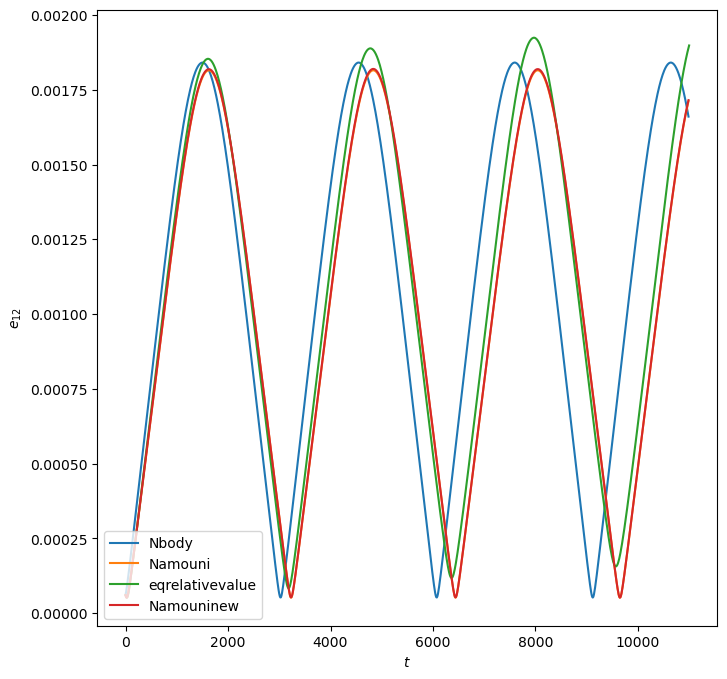

In [28]:
#plot to compare all versions
#both relative and individual versions of Namouni mapping should closely match
fig, ax5 = plt.subplots(figsize = (8,8))
ax5.set_xlabel('$t$')
ax5.set_ylabel('$e_{12}$')
ax5.plot(tbetweens, e12n, label='Nbody') # plot e12
ax5.plot(tbetweens,np.sqrt(2*Is)*epsilon, label='Namouni') # plot e12
ax5.plot(t, np.sqrt(soltconj[:,0]**2+soltconj[:,1]**2)*epsilon,label = 'eqrelativevalue')
ax5.plot(tbetweens,np.sqrt((e2_s[:,0]-e1_s[:,0])**2+(e2_s[:,1]-e1_s[:,1])**2),label='Namouninew') # plot e12
ax5.legend()
plt.savefig('eqvsnamouni2.png')

Another important parameter to consider is $\varpi$, the longitude of periapsis. This is used to parameterize the direction of the eccentricity vector and acts as a reference location (the position of the pericenter) to start measuring the mean longitude. A deviation in this can cause a deviation in the conjunction angle.

In [29]:
pomega_s= np.arctan2((e2_s[:,1]-e1_s[:,1]),(e2_s[:,0]-e1_s[:,0]))
pomega_s

array([ 3.14129019, -2.90059658, -2.61831264, ..., -2.09925114,
       -2.10658549, -2.1139899 ])

In [30]:
phis

array([-3.14159265, -2.90091324, -2.61941625, ..., -2.09929496,
       -2.10663209, -2.11403934])

In [31]:
pomega_eq = np.arctan2(soltconj[:,1],soltconj[:,0])
pomega_eq

array([-3.14159265, -2.89218575, -2.600366  , ..., -1.99303636,
       -2.00028598, -2.00760525])

In [32]:
phi_from_e = np.arctan2(ks, hs)
phi_from_e

array([ 0.        , -2.90091324, -2.61941625, ..., -2.09929496,
       -2.10663209, -2.11403934])

In [33]:
pomega_eq2 = soltconj[:,3]

This can change over time as well due to the orbital wobble after each interaction, and it can affect the position of the conjunction as we have to start measuring the mean longitude from the pericenter. Also see that at low eccentricity, none of the models would match Nbody if they are the first order.

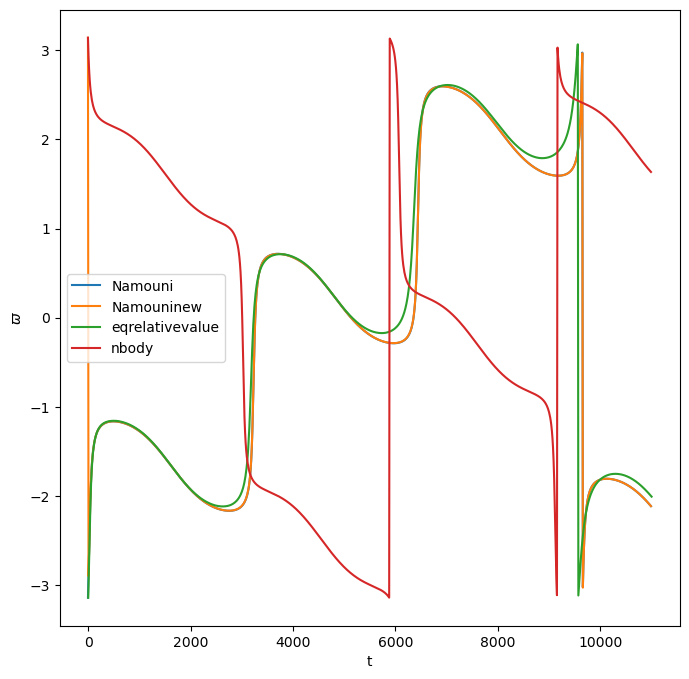

In [34]:
fig, ax6 = plt.subplots(figsize=(8,8))
ax6.set_ylabel(r'$\varpi$')
ax6.set_xlabel("t")
ax6.plot(tbetweens, phis, label="Namouni")
ax6.plot(tbetweens, pomega_s, label="Namouninew")
ax6.plot(t,pomega_eq,label="eqrelativevalue")
ax6.plot(tbetweens,pomegan,label="nbody")
ax6.legend()

We can also try to plot the mean longitude $\lambda$. All models and Nbody should follow the same pattern.

In [35]:
pomega2_conj

array([ 1.58835915,  2.45843905,  1.35865906, ..., -0.45112934,
       -0.53926326, -0.67885364])

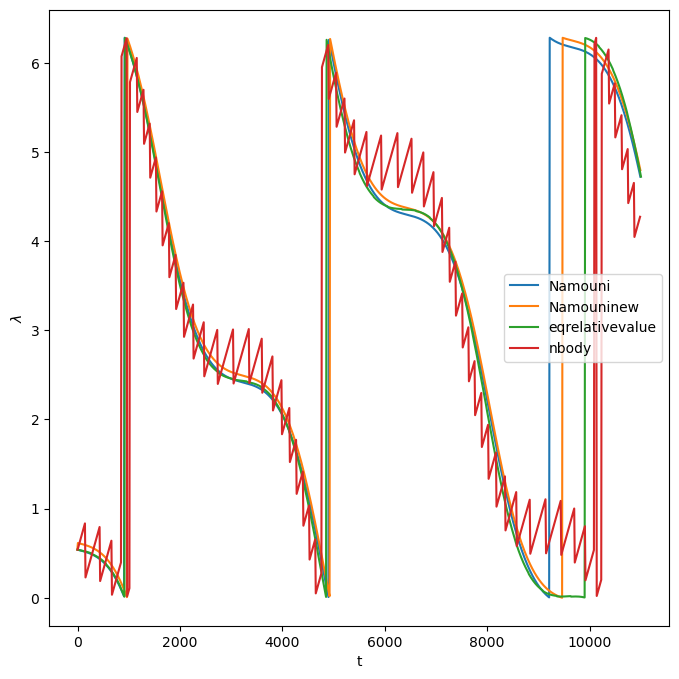

In [36]:
fig, ax6 = plt.subplots(figsize=(8,8))
ax6.set_ylabel(r'$\lambda$')
ax6.set_xlabel("t")
ax6.plot(tbetweens, lambdas%(2*np.pi), label="Namouni")
ax6.plot(tbetweens, lambda_s%(2*np.pi), label="Namouninew")
ax6.plot(t,soltconj[:,3]%(2*np.pi),label="eqrelativevalue")
ax6.plot(tconjs,l2[conj_idx]%(2*np.pi),label="nbody")
ax6.legend()

We can also plot the conjunction angle $\theta=\lambda-\varpi$. The mismatch in $\varpi$ in different models could cause the mismatch in $\theta$.

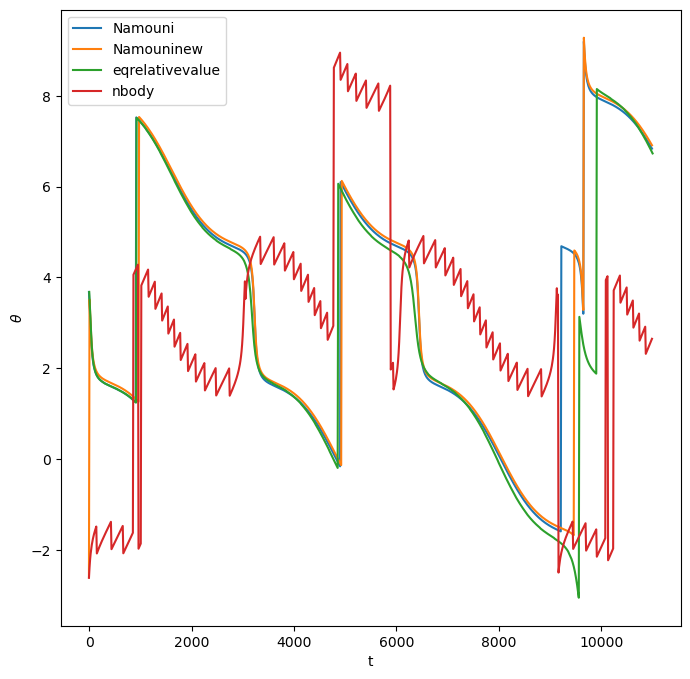

In [38]:
fig, ax6 = plt.subplots(figsize=(8,8))
ax6.set_ylabel(r'$\theta$')
ax6.set_xlabel("t")
ax6.plot(tbetweens, lambdas%(2*np.pi)-phis, label="Namouni")
ax6.plot(tbetweens, lambda_s%(2*np.pi)-pomega_s, label="Namouninew")
ax6.plot(t,soltconj[:,3]%(2*np.pi)-pomega_eq,label="eqrelativevalue")
ax6.plot(tbetweens,l2[btwn_conj_idx]%(2*np.pi)-pomegan,label="nbody")
ax6.legend()